# Week 5
source for AV: https://www.linkedin.com/pulse/practical-guide-adversarial-validation-lu%C3%ADs-fernando-torres/

Goals of this notebook:
* Get test, train, validation split of data, stratified on isFraud
* Perform Adversarial Validation to see what is in test, train, and validation sets when compared to each other

Limitation: To preserve RAM for analysis, I used the first half of the csv. Any more than that, and the RAM fails when I run the notebook.

In [19]:
# set up
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


In [18]:
# load data
transaction = pd.read_csv('/content/train_transaction_clean.csv')

KeyboardInterrupt: 

In [ ]:
# create identity flag
# identity = pd.read_csv('/content/train_identity.csv')

# identity['TransactionID'] = identity['TransactionID'].astype(str)
# if a transactionID is in both datasets, flag it
# transaction['hasID'] = transaction['TransactionID'].astype(str).isin(identity['TransactionID']).astype(int)

Step 1: Test/Train/Validation Split
* Train: 60%
* Test: 20%
* Validation: 20%

Stratified on isFraud

In [20]:
# get data ready for split
X = transaction.drop('isFraud', axis=1)
y = transaction['isFraud']

In [21]:
# split 1: isolate training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=42, stratify=y)


In [22]:
# export train and test as csv
train = pd.concat([X_train, y_train], axis = 0)
test = pd.concat([X_test, y_test], axis = 0)

# remember to split a second time 50/50 when doing the actual analysis to preserve the test/validation split
train.to_csv(path_or_buf='/content/train_transaction2.csv')
test.to_csv(path_or_buf='/content/test_val_transaction.csv')

## Adversarial Validation

Adversarial Validation sees how similar the test, train, and validation sets are to each other. The goal of this analysis to see where the test and train sets differ to prevent overfitting in the future

In [23]:
# add flags to show what data set the records come from
# 0 = train, 1 = test/val

X_train['isTrain'] = 1
X_test['isTrain'] = 0

X_all = pd.concat([X_train, X_test], axis = 0)
df = X_all.sample(frac = 1, random_state = 472)


In [24]:
cat_features = list(df.select_dtypes(include=['object']).columns)

cat_features

['ProductCD',
 'card4',
 'card6',
 'P_emaildomain',
 'R_emaildomain',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9']

In [25]:
df_cat = df[cat_features].astype("category")
df_int = df.drop(cat_features, axis=1)

df = pd.concat([df_cat, df_int], axis = 1)

df.head()

,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,V283,V289,V296,V301,V314,V332,V325,V335,hasID,isTrain
6332,W,mastercard,debit,yahoo.com,NaN,NaN,NaN,NaN,M0,T,...,1.0,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,0.0,0
15321,R,american express,credit,anonymous.com,anonymous.com,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,1
12128,W,mastercard,debit,NaN,NaN,T,T,T,M0,F,...,1.0,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,0.0,0
14592,W,mastercard,debit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,0.0,0.0,93.900002,NaN,NaN,NaN,0.0,1
7026,W,mastercard,debit,yahoo.com,NaN,T,T,T,M0,F,...,1.0,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,0.0,1


In [26]:
# Splitting Data
X_av = df.drop(['isTrain'], axis = 1)
y_av = df['isTrain']

In [27]:
cv = StratifiedKFold(n_splits = 6, shuffle = True, random_state = 472)

In [28]:
xgb_model = XGBClassifier(max_depth=3,
                          learning_rate = 0.01,
                          n_estimators = 100,
                          objective = 'binary:logistic',
                          enable_categorical=True,
                          random_state = 472)

In [29]:
av_scores = []

cv = cv.split(X_av,y_av)

for _, (train_val, test_val) in enumerate(cv):
    X_train = X_av.iloc[train_val]
    X_test = X_av.iloc[test_val]
    y_train = y_av.iloc[train_val]
    y_test = y_av.iloc[test_val]

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test, y_pred)
    av_scores.append(score)

    print(f"Fold AUC Score: {score:.5f}")

Fold AUC Score: 0.48184
Fold AUC Score: 0.49207
Fold AUC Score: 0.49452
Fold AUC Score: 0.49109
Fold AUC Score: 0.48407
Fold AUC Score: 0.48211


Having a low fold AUC score is good, because it means that the model is having a hard time differentiating between the test and train sets. Therfore, there is no glaring issue with the split and both represent each other well. It's about as good as random guessing.

Text(0, 0.5, 'True Positive Rate')

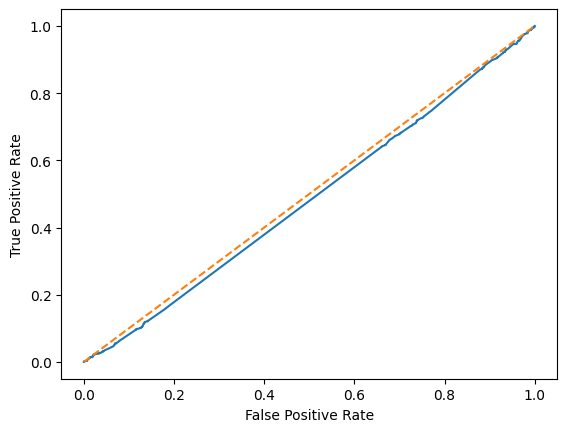

In [30]:
# plot the AUC scores

mean_scores = np.mean(av_scores)
false_positives, true_positives, _ = roc_curve(y_test, y_pred)
plt.plot(false_positives, true_positives, label = f'ROC Curve (AUC = {mean_scores})')
plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='C1')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

Even though its accuracy is low and telling the test/train data apart is not easy, we can see which features are most important in differentiating the two datasets.

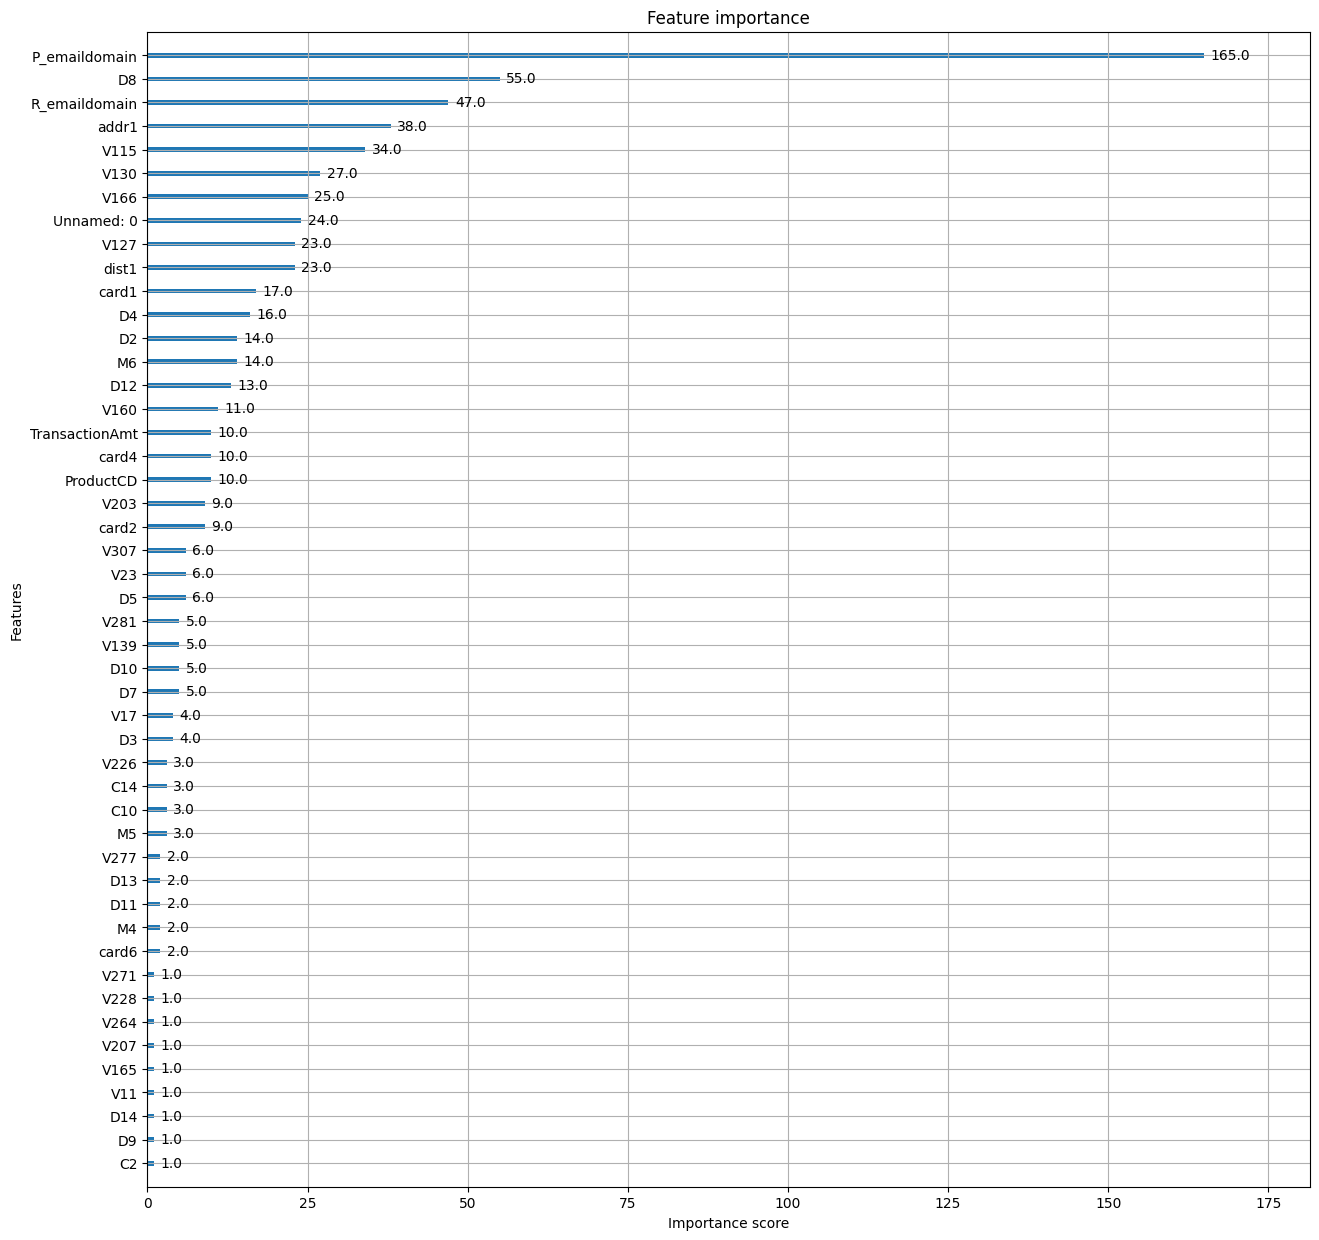

In [31]:
# understand which features are most important to the model, which tells us about which features are similar across the test/train split
ax = plot_importance(xgb_model)
fig = ax.figure
fig.set_size_inches(15, 15)

Email domain was the most useful for evaluating the train test split, which tracks becuase its a unique identifier for a person. D8 also was similar across splits.